In [1]:
from ema_workbench import load_results

experiments, outcomes = load_results('ema_resultsprobstate3.tar.gz')

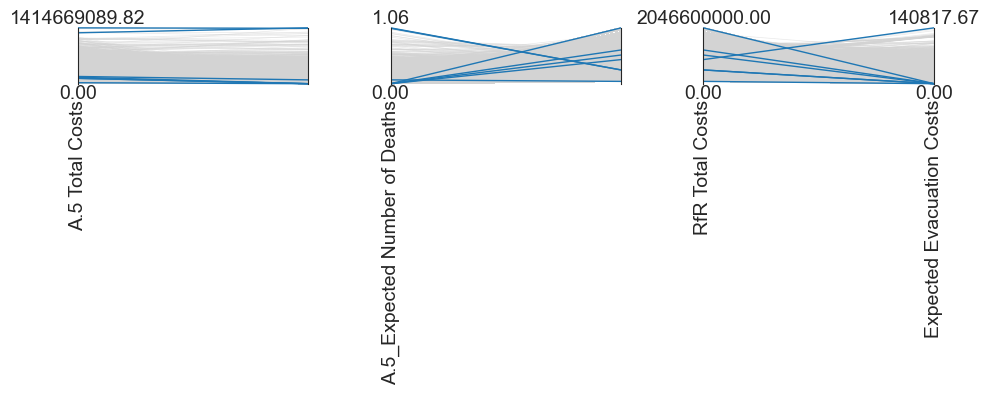

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from ema_workbench.analysis import parcoords

# Combine all outcomes into a single DataFrame
all_data = pd.DataFrame({k: v for k, v in outcomes.items()})

# Focus only on selected outcomes
selected_outcomes = [
    'A.5 Total Costs',
    'A.5_Expected Number of Deaths',
    'RfR Total Costs',
    'Expected Evacuation Costs'
]
all_data = all_data[selected_outcomes]

# Get indices of rows with min and max values across outcomes
indices = pd.concat([all_data.idxmax(), all_data.idxmin()]).unique()

# Create axis limits and force min to 0
limits = parcoords.get_limits(all_data)
limits.loc[0, selected_outcomes] = 0

# Initialize parallel coordinates plot
axes = parcoords.ParallelAxes(limits)

# Plot all lines in grey with transparency
axes.plot(all_data, color='lightgrey', lw=0.5, alpha=0.5)

# Highlight rows with extreme values
axes.plot(all_data.loc[indices], color=sns.color_palette()[0], lw=1)

# Final layout
fig = plt.gcf()
fig.set_size_inches((10, 4))  # wider if needed
plt.tight_layout()
plt.show()


In [4]:
print(all_data.idxmax())
print(all_data.idxmin())

A.5 Total Costs                   50223
A.5_Expected Number of Deaths     50327
RfR Total Costs                  245100
Expected Evacuation Costs         15504
dtype: int64
A.5 Total Costs                  44402
A.5_Expected Number of Deaths        0
RfR Total Costs                  11100
Expected Evacuation Costs            0
dtype: int64


In [9]:
# also all we need are the uncertainty columns
#worst case scenario
selected = experiments.loc[[50223, 50327, 245100,15504], ['A.1_Brate',
'A.2_Bmax',
'A.2_pfail',
'A.2_Brate',
'A.3_Bmax',
'A.3_pfail',
'A.3_Brate',
'A.4_Bmax',
'A.4_pfail',
'A.4_Brate',
'A.5_Bmax',
'A.5_pfail',
'A.5_Brate']]
selected

,A.1_Brate,A.2_Bmax,A.2_pfail,A.2_Brate,A.3_Bmax,A.3_pfail,A.3_Brate,A.4_Bmax,A.4_pfail,A.4_Brate,A.5_Bmax,A.5_pfail,A.5_Brate
50223,10.0,178.422198,0.782889,10.0,75.159914,0.326466,1.5,163.036732,0.352907,10.0,128.544421,0.021409,1.0
50327,1.0,49.546161,0.764653,10.0,114.294251,0.990497,10.0,195.733383,0.186022,10.0,279.544972,0.002193,10.0
245100,1.5,58.229759,0.868944,10.0,118.279228,0.140612,10.0,337.151963,0.485097,1.5,228.707630,0.349678,1.5
15504,1.5,125.656646,0.036213,1.0,256.515881,0.030604,1.0,214.704493,0.245326,10.0,83.055424,0.257775,1.5


In [10]:
#toevoegen aan lijst van scenarios
from ema_workbench import Scenario

scenarios = [Scenario(f"{index}", **row) for index, row in selected.iterrows()]

In [15]:
from sklearn import preprocessing
y = outcomes['A.5_Expected Number of Deaths'] < 0.000000001

experiments_of_interest = experiments.loc[y]
outcomes_df = pd.DataFrame({k:v[y] for k,v in outcomes.items()})

# normalize outcomes on unit interval to ensure equal weighting of outcomes
x = outcomes_df.values
min_max_scaler = preprocessing.MinMaxScaler()
x_scaled = min_max_scaler.fit_transform(x)
normalized_outcomes = pd.DataFrame(x_scaled, columns=outcomes_df.columns)

In [ ]:
import itertools

n_scen = experiments.loc[y].shape[0]
indices = range(n_scen)
set_size = 4
n_scen
combinations = itertools.combinations(indices, set_size)
combinations = list(combinations)